In [250]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [251]:
review = pd.read_json(r"C:\Users\songu\Downloads\Grocery_and_Gourmet_Food.jsonl\Grocery_and_Gourmet_Food.jsonl", lines = True, nrows = 100000 ) 
review

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Excellent! Yummy!,Excellent!! Yummy! Great with other foods and...,[],B00CM36GAQ,B00CM36GAQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:41:22.395,0,True
1,5,Delicious!!! Yum!,Excellent! The best! I use it with my beef a...,[],B074J5WVYH,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:40:00.380,0,True
2,5,"Extremely Delicious, but expensive imo",These are very tasty. They are extremely soft ...,[],B079TRNVHX,B079TRNVHX,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:20:24.527,1,True
3,5,Delicious!,My favorite!,[],B07194LN2Z,B07194LN2Z,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:59.614,0,True
4,5,Great taste,Great for making brownies and crinkle cookies.,[],B005CD4196,B005CD4196,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:34.965,7,True
...,...,...,...,...,...,...,...,...,...,...
99995,5,Delicious!,Love these flavor popcorn. And low fat. Win win.,[],B08W8Q2PTM,B08W8Q2PTM,AEFVW4PUVKW4AOPZTZVXWN4I7PEQ,2021-07-23 21:31:25.883,0,True
99996,5,Great sparkling water,"Bubly is my favorite! Prior, I used to drink L...",[],B078XXCDRS,B078XXCDRS,AEFVW4PUVKW4AOPZTZVXWN4I7PEQ,2019-06-17 16:00:09.369,0,True
99997,1,would not recommend.,artificial tasting. not a fan. would not recom...,[],B06XDL8D6B,B06XDL8D6B,AEFVW4PUVKW4AOPZTZVXWN4I7PEQ,2017-09-26 17:45:42.330,0,True
99998,5,Love that they come in four little squares,These are delicious. Love that they come in fo...,[],B013SJNIH6,B078Y5R2YJ,AEFVW4PUVKW4AOPZTZVXWN4I7PEQ,2016-06-20 16:33:16.000,0,True


In [252]:
#use parent_asin to group product together
review = review[['rating','parent_asin','user_id','timestamp']]
review.head()

,rating,parent_asin,user_id,timestamp
0,5,B00CM36GAQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:41:22.395
1,5,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:40:00.380
2,5,B079TRNVHX,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:20:24.527
3,5,B07194LN2Z,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:59.614
4,5,B005CD4196,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:34.965


In [253]:
review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   rating       100000 non-null  int64         
 1   parent_asin  100000 non-null  object        
 2   user_id      100000 non-null  object        
 3   timestamp    100000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 3.1+ MB


In [254]:
review.isnull().sum()

rating         0
parent_asin    0
user_id        0
timestamp      0
dtype: int64

In [255]:
review.describe()

,rating,timestamp
count,100000.000000,100000
mean,4.314320,2019-09-03 20:55:35.324903424
min,1.000000,2003-10-16 10:30:16
25%,4.000000,2018-04-03 12:06:42.764999936
50%,5.000000,2020-04-23 20:27:00.225499904
75%,5.000000,2021-09-02 17:23:34.014749952
max,5.000000,2023-03-17 11:30:32.209000
std,1.188544,NaN


In [256]:
review.duplicated(subset=['user_id','parent_asin']).sum()


np.int64(2116)

In [257]:
review = review.drop_duplicates(subset=['user_id','parent_asin'])
review.duplicated(subset=['user_id','parent_asin']).sum()



np.int64(0)

In [258]:
grocery = pd.read_json(r"C:\Users\songu\Downloads\meta_Gift_Cards.jsonl\meta_Gift_Cards.jsonl", lines = True, nrows = 100000)
grocery = grocery[['title','average_rating','rating_number','description','parent_asin']]

In [259]:
grocery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           1137 non-null   object 
 1   average_rating  1137 non-null   float64
 2   rating_number   1137 non-null   int64  
 3   description     1137 non-null   object 
 4   parent_asin     1137 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 44.5+ KB


In [260]:
grocery.isnull().sum()

title             0
average_rating    0
rating_number     0
description       0
parent_asin       0
dtype: int64

In [261]:
grocery.duplicated('parent_asin').sum()

np.int64(0)

In [262]:
review.head()

,rating,parent_asin,user_id,timestamp
0,5,B00CM36GAQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:41:22.395
1,5,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:40:00.380
2,5,B079TRNVHX,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:20:24.527
3,5,B07194LN2Z,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:59.614
4,5,B005CD4196,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:34.965


In [263]:
grocery.head()

,title,average_rating,rating_number,description,parent_asin
0,Amazon.com Gift Card in Gift Tag (Various Desi...,4.8,1006,[Amazon.com Gift Cards are the perfect way to ...,B06ZXTKYHN
1,$25 Mastercard Gift Card (plus $3.95 Purchase ...,2.5,11,[Mastercard Gift Cards are the ideal gift – to...,B07FX2LXR4
2,Tractor Supply Company Gift Card,4.9,2708,[Tractor Supply Company is the largest operato...,B01GKWEISG
3,Staples Gift Card,4.8,351,[Giving the perfect gift has never been easier...,B00GOLH2S2
4,Ninety Nine Restaurants Gift Card,4.8,443,[The Ninety Nine Restaurants is a comfortable ...,B00BXLV3RO


In [264]:
n_ratings = len(review)
n_items = review['parent_asin'].nunique()
n_users = review['user_id'].nunique()

print(f"Number of total review: {n_ratings} ")
print(f"Number of total items: {n_items}")
print(f"Number of total users: {n_users} ")
print(f"Average number of ratings per user: {round(n_ratings / n_users,2)} ")
print(f"Average number of ratings per item: {round(n_ratings / n_items,2)} ")

Number of total review: 97884 
Number of total items: 47961
Number of total users: 10459 
Average number of ratings per user: 9.36 
Average number of ratings per item: 2.04 


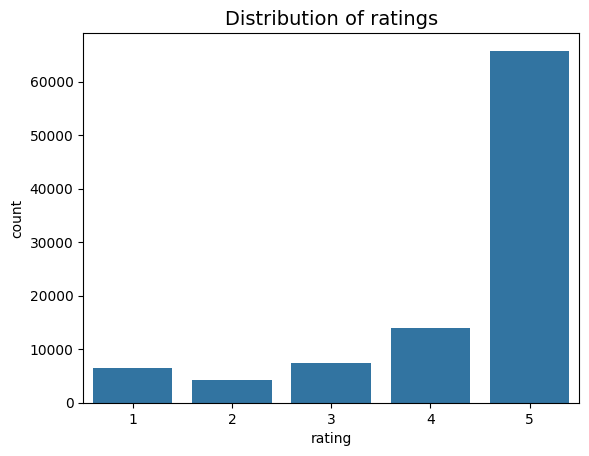

In [265]:
#Distribution of ratings 
sns.countplot(x= "rating", data = review )
plt.title("Distribution of ratings", fontsize = 14)
plt.show()

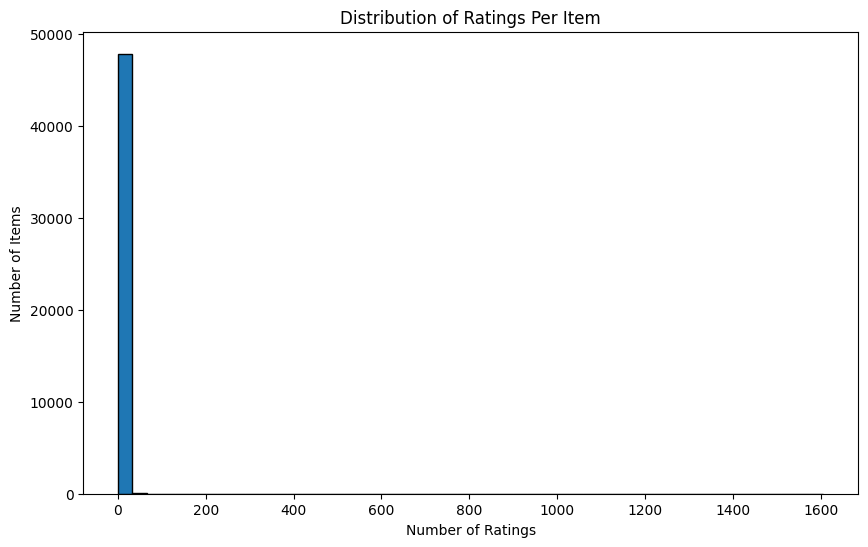

In [266]:
# This is the "ratings per item" distribution
ratings_per_item = review.groupby('parent_asin').size()

plt.figure(figsize=(10, 6))
plt.hist(ratings_per_item, bins=50, edgecolor='black')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Items')
plt.title('Distribution of Ratings Per Item')
plt.show()


In [267]:
#Pretty severe skewed data
ratings_per_item = review.groupby("parent_asin").size()
print(ratings_per_item.describe())

count    47961.000000
mean         2.040908
std         11.517894
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max       1605.000000
dtype: float64


In [268]:

user_fil = review.copy()  

iteration = 0

while True:
    iteration += 1
    
    n_users_before = user_fil['user_id'].nunique()
    n_items_before = user_fil['parent_asin'].nunique()
    
   
    item_counts = user_fil['parent_asin'].value_counts()
    valid_items = item_counts[item_counts >= 5].index
    user_fil = user_fil[user_fil['parent_asin'].isin(valid_items)]
    
   
    user_counts = user_fil['user_id'].value_counts()
    valid_users = user_counts[user_counts >= 5].index
    user_fil = user_fil[user_fil['user_id'].isin(valid_users)]
    
    n_users_after = user_fil['user_id'].nunique()
    n_items_after = user_fil['parent_asin'].nunique()
    
    print(f"Iteration {iteration}: {n_users_before}→{n_users_after} users, {n_items_before}→{n_items_after} items")
    
    if n_users_before == n_users_after and n_items_before == n_items_after:
        print("Converged!")
        break


print(f"\nMin item reviews: {user_fil['parent_asin'].value_counts().min()}")
print(f"Min user reviews: {user_fil['user_id'].value_counts().min()}")

Iteration 1: 10459→1650 users, 47961→3020 items
Iteration 2: 1650→1422 users, 3020→2096 items
Iteration 3: 1422→1391 users, 2096→1996 items
Iteration 4: 1391→1386 users, 1996→1981 items
Iteration 5: 1386→1385 users, 1981→1980 items
Iteration 6: 1385→1385 users, 1980→1979 items
Iteration 7: 1385→1385 users, 1979→1979 items
Converged!

Min item reviews: 5
Min user reviews: 5


In [269]:
print(user_fil.shape)
user_fil.head()

(18826, 4)


,rating,parent_asin,user_id,timestamp
0,5,B00CM36GAQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:41:22.395
1,5,B0759B7KLH,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:40:00.380
2,5,B079TRNVHX,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-04-25 22:20:24.527
3,5,B07194LN2Z,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:59.614
4,5,B005CD4196,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-10 05:41:34.965


In [270]:
global_mean = round(user_fil["rating"].mean(),2)
print(f"The average score of all ratings: {global_mean}")

The average score of all ratings: 4.41


In [271]:
user_mean_ratings = user_fil.groupby("user_id")["rating"].mean()
user_mean_ratings

print(f"Mean rating per user: {round(user_mean_ratings.mean(),2)}")

Mean rating per user: 4.4


In [272]:
item_ratings = user_fil.merge(grocery, on= "parent_asin")
item_ratings 

,rating,parent_asin,user_id,timestamp,title,average_rating,rating_number,description


In [273]:
#How frequennt does the item get rated
item_fre = item_ratings['parent_asin'].value_counts().reset_index()
item_fre



,parent_asin,count


In [274]:
#List of rating
top_list = item_fre.merge(item_ratings, on= "parent_asin")
top_list
#count = what Ive captured from 100k lines
#rating_number = total ratings of that item

,parent_asin,count,rating,user_id,timestamp,title,average_rating,rating_number,description


In [275]:
top_10 = item_ratings['title'].value_counts()[0:10]
top_10


Series([], Name: count, dtype: int64)

In [276]:
# Lowest 10
unique = top_list[['parent_asin','count', 'title', 'average_rating']].drop_duplicates(subset='parent_asin') #subset drop identical product ID
lowest_10 = unique.sort_values('average_rating').head(10)
lowest_10

,parent_asin,count,title,average_rating


In [277]:
#Highest 10
highest_10 = unique.sort_values('average_rating', ascending= False ).head(10)
highest_10 

,parent_asin,count,title,average_rating


Some products have very high scores from only a few ratings, while others have slightly lower scores but from many ratings, which can make comparisons unfair.

Bayesian Average

In [278]:
list_stat = user_fil.groupby("parent_asin")["rating"].agg(["count","mean","sum"])
list_stat.head(10)

,count,mean,sum
parent_asin,,,
B00017028M,12,5.000000,60
B0005Z6ZK4,8,4.625000,37
B00099XNXS,14,4.714286,66
B00099XOXM,19,3.789474,72
B00099XPD6,8,4.625000,37
B000E6LBXK,6,4.666667,28
B000FI701Y,5,4.400000,22
B000FIUQB0,5,4.800000,24
B000FIXYCS,8,4.250000,34


Use bayesian average as baseline model

First, I want to split dataset base on date to test on baseline model.

In [279]:
user_fil['timestamp'] = pd.to_datetime(user_fil["timestamp"])
user_fil_sorted = user_fil.sort_values("timestamp")

latest = user_fil_sorted.groupby("user_id")['timestamp'].idxmax()

test  = user_fil_sorted.loc[latest]
train = user_fil_sorted.drop(latest)

print(test.shape)
print(train.shape)


(1385, 4)
(17441, 4)


In [280]:
train_stats = train.groupby("parent_asin")["rating"].agg(["count","mean","sum"])
C = train_stats["count"].mean()
M = train_stats["mean"].mean()

print(f"Average of number of ratings for a given item: {C:0.2f}")
print(f"Average rating of given item: {M:0.2f} ")

Average of number of ratings for a given item: 8.81
Average rating of given item: 4.40 


In [281]:
def bayes(ratings):
    bayesian_avg = (C * M + ratings.sum()) / (C + ratings.count())
    return round(bayesian_avg, 3)


Apply Bayesian to dataset

In [282]:
bay = train.groupby("parent_asin")["rating"].agg(bayes).reset_index()
item_stat = list_stat.merge(bay, on = "parent_asin")
item_stat

,parent_asin,count,mean,sum,rating
0,B00017028M,12,5.000000,60,4.702
1,B0005Z6ZK4,8,4.625000,37,4.474
2,B00099XNXS,14,4.714286,66,4.592
3,B00099XOXM,19,3.789474,72,4.221
4,B00099XPD6,8,4.625000,37,4.505
...,...,...,...,...,...
1974,B0CDFWB1YQ,5,4.400000,22,4.351
1975,B0CDLRTR5L,8,4.500000,36,4.411
1976,B0CF271RSQ,8,4.500000,36,4.641
1977,B0CFYXN8ZQ,7,4.285714,30,4.348


In [283]:
item_stat = item_stat.merge(grocery[["parent_asin","title"]]).drop_duplicates(subset="parent_asin")
item_stat

,parent_asin,count,mean,sum,rating,title


In [285]:
def precision_at_k(recommended, actual, k=10):
    recommended_k = recommended[:k]
    matches = set(recommended_k) & set(actual)
    num_matches = len(matches)
    precision = num_matches / k
    return precision


In [286]:
def recall_at_k(recommended, actual, k=10):
    
    if len(actual) == 0:
        return 0.0
   
    recommended_k = recommended[:k]
    matches = set(recommended_k) & set(actual)
    
    num_matches = len(matches)
    
    recall = num_matches / len(actual)
    return recall